In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
import sklearn, numpy, spacy
print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("spacy:", spacy.__version__)


sklearn: 1.6.1
numpy: 2.0.2
spacy: 3.8.11


In [ ]:
#load dataset
df = pd.read_csv('final_dataset.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37991 entries, 0 to 37990
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   article_id             37991 non-null  object 
 1   sentence_index         37991 non-null  int64  
 2   normalized_position    37991 non-null  float64
 3   sentence_length_words  37991 non-null  int64  
 4   tfidf_sim_article      37991 non-null  float64
 5   ner_count              37991 non-null  int64  
 6   has_digit              37991 non-null  int64  
 7   stop_ratio             37991 non-null  float64
 8   textrank_score         37991 non-null  float64
 9   label                  37991 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 2.9+ MB


In [ ]:
FEATURE_COLS = [

    "normalized_position",
    "sentence_length_words",
    "tfidf_sim_article",
    "ner_count",
    "has_digit",
    "stop_ratio",
    "textrank_score"
]


In [ ]:
#collect all unique article IDs
#we are gonna split the data at article level
article_ids = df["article_id"].unique()

#splitting the dataset
#split 1
#train dataset 70% and temporary split (validation split + test split)
train_article_ids, temp_article_ids = train_test_split(article_ids,test_size=0.30,random_state=42,shuffle=True)
#split 2
#splitting the temporary split to validation dataset and testing dataset
val_article_ids, test_article_ids = train_test_split(temp_article_ids,test_size=0.50,random_state=42,shuffle=True)

In [ ]:
#create the final dataframe by matching the sentences from each articles
train_df = df[df["article_id"].isin(train_article_ids)]
val_df   = df[df["article_id"].isin(val_article_ids)]
test_df  = df[df["article_id"].isin(test_article_ids)]

In [ ]:
#check for proper splitting
assert set(train_article_ids).isdisjoint(val_article_ids)
assert set(train_article_ids).isdisjoint(test_article_ids)
assert set(val_article_ids).isdisjoint(test_article_ids)

print(" Article-wise split done correctly (No leakage)")


 Article-wise split done correctly (No leakage)


In [ ]:
X_train = train_df[FEATURE_COLS]
y_train = train_df["label"]

X_val = val_df[FEATURE_COLS]
y_val = val_df["label"]

X_test = test_df[FEATURE_COLS]
y_test = test_df["label"]


In [ ]:
#model building
#standardScaler() -standardize the features
#class_weight="balanced" - as data has huge class imbalance the model is forced to focus on imp class
#pipeline -to prevent the preprocessing leakage
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])


In [ ]:
#fitt the model
lr_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
#validation evaluation
y_val_pred = lr_pipeline.predict(X_val)

print("VALIDATION PERFORMANCE")
print(classification_report(y_val, y_val_pred))


VALIDATION PERFORMANCE
              precision    recall  f1-score   support

           0       0.97      0.76      0.85      4995
           1       0.26      0.78      0.39       547

    accuracy                           0.76      5542
   macro avg       0.62      0.77      0.62      5542
weighted avg       0.90      0.76      0.81      5542



In [ ]:
# Step 1: Get importance probabilities for validation set
val_probs = lr_pipeline.predict_proba(X_val)[:, 1]

# Step 2: Attach probabilities back to validation dataframe
val_results = val_df.copy()
val_results["importance_score"] = val_probs

# Step 3: Generate top-N sentences per article
TOP_N = 5

val_summary = (
    val_results
    .sort_values(["article_id", "importance_score"], ascending=[True, False])
    .groupby("article_id")
    .head(TOP_N)
    .sort_values(["article_id", "sentence_index"])
)

print("TOP SENTENCES PER ARTICLE")
val_summary.head(10)


TOP SENTENCES PER ARTICLE


,article_id,sentence_index,normalized_position,sentence_length_words,tfidf_sim_article,ner_count,has_digit,stop_ratio,textrank_score,label,importance_score
124,011cfe059bfddd7dc3be107e5ec4502bc5b09abd,0,0.000000,29,0.328606,2,0,0.482759,0.145951,0,0.941512
125,011cfe059bfddd7dc3be107e5ec4502bc5b09abd,1,0.166667,21,0.759648,3,0,0.333333,0.203538,1,0.998845
126,011cfe059bfddd7dc3be107e5ec4502bc5b09abd,2,0.333333,33,0.737784,2,0,0.393939,0.183903,0,0.996628
128,011cfe059bfddd7dc3be107e5ec4502bc5b09abd,4,0.666667,20,0.592453,3,0,0.400000,0.172695,1,0.985204
129,011cfe059bfddd7dc3be107e5ec4502bc5b09abd,5,0.833333,17,0.352009,1,1,0.352941,0.141832,1,0.816351
152,0132a4a7b0ae6842a36af6eff1dfdaf8f2beb3a0,0,0.000000,34,0.343774,6,0,0.323529,0.020214,0,0.746128
155,0132a4a7b0ae6842a36af6eff1dfdaf8f2beb3a0,3,0.050847,18,0.391874,2,0,0.333333,0.024111,1,0.780318
156,0132a4a7b0ae6842a36af6eff1dfdaf8f2beb3a0,4,0.067797,19,0.340363,5,1,0.210526,0.022141,1,0.759065
157,0132a4a7b0ae6842a36af6eff1dfdaf8f2beb3a0,5,0.084746,18,0.385666,3,1,0.444444,0.024622,1,0.822646
162,0132a4a7b0ae6842a36af6eff1dfdaf8f2beb3a0,10,0.169492,11,0.466290,4,1,0.272727,0.028558,1,0.893199


In [ ]:
from sklearn.metrics import classification_report, f1_score, precision_score
from sklearn.model_selection import ParameterGrid

In [ ]:
param_grid = {
    "C": [0.01, 0.1, 1.0],
    "class_weight": [
        {0: 1, 1: 1},
        {0: 1, 1: 2},
        {0: 1, 1: 3}
    ],
    "solver": ["liblinear"]
}


In [ ]:
best_model = None
best_params = None
best_f1 = 0

for params in ParameterGrid(param_grid):
    model = LogisticRegression(
        **params,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)

    f1 = f1_score(y_val, y_val_pred, pos_label=1)

    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_params = params


In [ ]:
print("Best parameters (before threshold tuning):")
print(best_params)

print("\nValidation Performance (threshold = 0.5):")
print(classification_report(y_val, best_model.predict(X_val)))


Best parameters (before threshold tuning):
{'C': 1.0, 'class_weight': {0: 1, 1: 3}, 'solver': 'liblinear'}

Validation Performance (threshold = 0.5):
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      4995
           1       0.39      0.46      0.42       547

    accuracy                           0.88      5542
   macro avg       0.66      0.69      0.68      5542
weighted avg       0.89      0.88      0.88      5542



In [ ]:
y_val_probs = best_model.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.3, 0.9, 0.05)

MIN_RECALL = 0.65   # minimum acceptable recall for class 1
from sklearn.metrics import precision_score, recall_score, f1_score

best_threshold = 0.5
best_precision = 0
best_metrics = None

for t in thresholds:
    y_val_pred_thresh = (y_val_probs >= t).astype(int)

    precision = precision_score(y_val, y_val_pred_thresh, pos_label=1, zero_division=0)
    recall = recall_score(y_val, y_val_pred_thresh, pos_label=1, zero_division=0)
    f1 = f1_score(y_val, y_val_pred_thresh, pos_label=1, zero_division=0)

    # enforce recall constraint
    if recall >= MIN_RECALL and precision > best_precision:
        best_precision = precision
        best_threshold = t
        best_metrics = (precision, recall, f1)

final_preds = (y_val_probs >= best_threshold).astype(int)

print("Chosen Threshold:", best_threshold)
print("Precision, Recall, F1 (class 1):", best_metrics)

print("\nFinal Validation Performance:")
print(classification_report(y_val, final_preds))


Chosen Threshold: 0.35
Precision, Recall, F1 (class 1): (0.32427695004382123, 0.676416819012797, 0.43838862559241704)

Final Validation Performance:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      4995
           1       0.32      0.68      0.44       547

    accuracy                           0.83      5542
   macro avg       0.64      0.76      0.67      5542
weighted avg       0.90      0.83      0.85      5542



In [ ]:
#combine train and val for final testing
import numpy as np

X_train_final = np.vstack([X_train, X_val])
y_train_final = np.concatenate([y_train, y_val])


In [ ]:
#freeze model
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(
    C=1.0,
    class_weight={0: 1, 1: 3},
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

final_model.fit(X_train_final, y_train_final)

FINAL_THRESHOLD = 0.35


In [ ]:
from sklearn.metrics import classification_report

y_test_probs = final_model.predict_proba(X_test)[:, 1]
y_test_preds = (y_test_probs >= FINAL_THRESHOLD).astype(int)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
print("FINAL TEST SET PERFORMANCE")
print("Threshold:", FINAL_THRESHOLD)
print(classification_report(y_test, y_test_preds))


FINAL TEST SET PERFORMANCE
Threshold: 0.35
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      5280
           1       0.33      0.60      0.42       562

    accuracy                           0.84      5842
   macro avg       0.64      0.74      0.67      5842
weighted avg       0.89      0.84      0.86      5842



In [ ]:
#summary generation

In [ ]:
# Step 1: Get importance probabilities for validation set
val_probs = lr_pipeline.predict_proba(X_val)[:, 1]

# Step 2: Attach probabilities back to validation dataframe
val_results = val_df.copy()
val_results["importance_score"] = val_probs

# Step 3: Generate top-N sentences per article
TOP_N = 5

val_summary = (
    val_results
    .sort_values(["article_id", "importance_score"], ascending=[True, False])
    .groupby("article_id")
    .head(TOP_N)
    .sort_values(["article_id", "sentence_index"])
)

print("TOP SENTENCES PER ARTICLE")
val_summary.head(10)


TOP SENTENCES PER ARTICLE


,article_id,sentence_index,normalized_position,sentence_length_words,tfidf_sim_article,ner_count,has_digit,stop_ratio,textrank_score,label,importance_score
124,011cfe059bfddd7dc3be107e5ec4502bc5b09abd,0,0.000000,29,0.328606,2,0,0.482759,0.145951,0,0.941512
125,011cfe059bfddd7dc3be107e5ec4502bc5b09abd,1,0.166667,21,0.759648,3,0,0.333333,0.203538,1,0.998845
126,011cfe059bfddd7dc3be107e5ec4502bc5b09abd,2,0.333333,33,0.737784,2,0,0.393939,0.183903,0,0.996628
128,011cfe059bfddd7dc3be107e5ec4502bc5b09abd,4,0.666667,20,0.592453,3,0,0.400000,0.172695,1,0.985204
129,011cfe059bfddd7dc3be107e5ec4502bc5b09abd,5,0.833333,17,0.352009,1,1,0.352941,0.141832,1,0.816351
152,0132a4a7b0ae6842a36af6eff1dfdaf8f2beb3a0,0,0.000000,34,0.343774,6,0,0.323529,0.020214,0,0.746128
155,0132a4a7b0ae6842a36af6eff1dfdaf8f2beb3a0,3,0.050847,18,0.391874,2,0,0.333333,0.024111,1,0.780318
156,0132a4a7b0ae6842a36af6eff1dfdaf8f2beb3a0,4,0.067797,19,0.340363,5,1,0.210526,0.022141,1,0.759065
157,0132a4a7b0ae6842a36af6eff1dfdaf8f2beb3a0,5,0.084746,18,0.385666,3,1,0.444444,0.024622,1,0.822646
162,0132a4a7b0ae6842a36af6eff1dfdaf8f2beb3a0,10,0.169492,11,0.466290,4,1,0.272727,0.028558,1,0.893199


In [ ]:
features_df=pd.read_csv('features.csv', engine='python', on_bad_lines='warn')
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37991 entries, 0 to 37990
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   article_id             37991 non-null  object 
 1   sentence_index         37991 non-null  int64  
 2   normalized_position    37991 non-null  float64
 3   sentence_length_words  37991 non-null  int64  
 4   tfidf_sim_article      37991 non-null  float64
 5   tfidf_sim_highlights   37991 non-null  float64
 6   ner_count              37991 non-null  int64  
 7   has_digit              37991 non-null  int64  
 8   stop_ratio             37991 non-null  float64
 9   textrank_score         37991 non-null  float64
 10  sentence_text          37991 non-null  object 
 11  highlights             37991 non-null  object 
dtypes: float64(5), int64(4), object(3)
memory usage: 3.5+ MB


In [ ]:
#summary generation
feature_cols = [
    "normalized_position",
    "sentence_length_words",
    "tfidf_sim_article",
    "ner_count",
    "has_digit",
    "stop_ratio",
    "textrank_score"
]

X_all = features_df[feature_cols].values


In [ ]:
#predict probabilities for sentences
features_df["importance_prob"] = final_model.predict_proba(X_all)[:, 1]

#rank the sentences
features_df = features_df.sort_values(
    by=["article_id", "importance_prob"],
    ascending=[True, False]
)
#top k sentences
TOP_K = 3
top_sentences_df = (
    features_df
    .groupby("article_id")
    .head(TOP_K)
)



In [ ]:
#get the original sentence order (better readiablity)
top_sentences_df = top_sentences_df.sort_values(
    by=["article_id", "sentence_index"]
)

#generate summary
generated_summaries = (
    top_sentences_df
    .groupby("article_id")["sentence_text"]
    .apply(lambda x: " ".join(x))
    .to_dict()
)
#reference summary
reference_summaries = (
    features_df
    .groupby("article_id")["highlights"]
    .first()
    .to_dict()
)




In [ ]:
for id,summary in generated_summaries.items():
    print(f"Article ID: {id}")
    print("Generated Summary:")
    print(summary)



Article ID: 002175ac42ef0c91b9fb7e07259413a8ee3979a3
Generated Summary:
Experts say there could be an influx of these barrel jellyfish – up to 3ft 2in in diameter – over the next few months due to warmer weather. In recent weeks, up to 10 barrel jellyfish have been spotted washed up on beaches around the South Coast. High numbers: In recent weeks, up to 10 barrel jellyfish have been spotted washed up on beaches around the south coast.
Article ID: 009e2c2f7a557cd6c431255707cf863f617076d6
Generated Summary:
There were no plans by Prime Minister Tony Abbott to send any of his ministers to global climate negotiations in Peru this week but Julie Bishop quickly got that changed. There were no plans by Prime Minister Tony Abbott (pictured left) to send any of his ministers to global climate negotiations in Peru this week but an uproar by Julie Bishop (pictured right) saw the decision reversed . The effort to bypass Prime Minister Tony Abbott (pictured) on global climate talks in Peru, shows e

In [ ]:
for id,summary in reference_summaries.items():
    print(f"Article ID: {id}")
    print("human written Summary:")
    print(summary)

Article ID: 002175ac42ef0c91b9fb7e07259413a8ee3979a3
human written Summary:
Latest in string of barrel jellyfish sightings reported on beach in Portland . Enormous creature was spotted by wildlife photographer Steve Trewhella . Comes days after a jellyfish the size of dustbin lid was sighted on island . Experts warn there could be influx of sea creatures as weather warms up . Forecasters expect temperatures to soar above 20C at the end of May .
Article ID: 009e2c2f7a557cd6c431255707cf863f617076d6
human written Summary:
A proposal by Julie Bishop, originally blocked, to travel to Peru for climate change talks was approved . The Foreign Affairs minister appealed to the full cabinet and the decision made by Tony Abbott was reversed . Ms Bishop will arrive in Lima on Tuesday to meet with around 200 countries to talk international climate policy . A recent poll indicated voters have little confidence in the Abbott government on climate change .
Article ID: 00a7e6767322697aa9236e2135aecc9785

In [ ]:
print("Total articles in features_df:", features_df["article_id"].nunique())
print("Train articles:", len(train_article_ids))
print("Test articles:", len(test_article_ids))

Total articles in features_df: 1000
Train articles: 700
Test articles: 150


In [ ]:
set(features_df["article_id"]).issubset(set(test_article_ids))

False

In [ ]:
set(features_df["article_id"]).issubset(set(val_article_ids))

False

In [ ]:
#Evaluation of summaries using ROUGE
candidates = []
references = []

for aid in generated_summaries:
    # safety check
    if aid in reference_summaries:
        candidates.append(generated_summaries[aid])
        references.append(reference_summaries[aid])


In [ ]:
#insatll and import ROUGE
!pip install rouge-score


In [ ]:
from rouge_score import rouge_scorer

In [ ]:
scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for ref, cand in zip(references, candidates):
    scores = scorer.score(ref, cand)
    rouge1_scores.append(scores["rouge1"].fmeasure)
    rouge2_scores.append(scores["rouge2"].fmeasure)
    rougeL_scores.append(scores["rougeL"].fmeasure)

print("ROUGE-1 F1:", np.mean(rouge1_scores))
print("ROUGE-2 F1:", np.mean(rouge2_scores))
print("ROUGE-L F1:", np.mean(rougeL_scores))


ROUGE-1 F1: 0.3466594301053264
ROUGE-2 F1: 0.1376063354644717
ROUGE-L F1: 0.22734324046311355


In [ ]:
#BERT score evaluation
#right now it is commented out because it takes to much time load bert
#this was the last evaluation score we got
#BERTScore Precision: 0.34497836232185364
#BERTScore Recall: 0.43270617723464966
#BERTScore F1: 0.38699159026145935
'''!pip install bert-score'''

'!pip install bert-score'

In [ ]:
'''from bert_score import score'''

'from bert_score import score'

In [ ]:
'''P, R, F1 = score(
    candidates,
    references,
    model_type="distilbert-base-uncased",
    lang="en",
    rescale_with_baseline=True
)
print("BERTScore Precision:", P.mean().item())
print("BERTScore Recall:", R.mean().item())
print("BERTScore F1:", F1.mean().item())'''

'P, R, F1 = score(\n    candidates,\n    references,\n    model_type="distilbert-base-uncased",\n    lang="en",\n    rescale_with_baseline=True\n)\nprint("BERTScore Precision:", P.mean().item())\nprint("BERTScore Recall:", R.mean().item())\nprint("BERTScore F1:", F1.mean().item())'

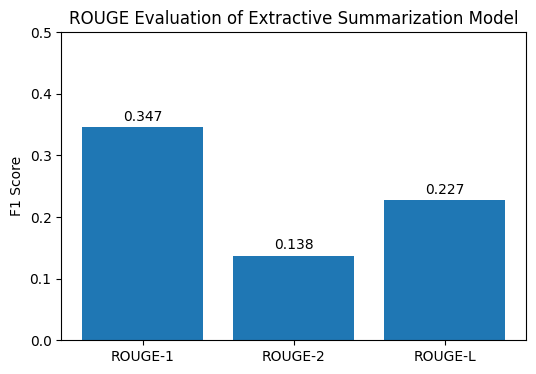

In [ ]:
import matplotlib.pyplot as plt

# Your ROUGE scores
rouge_scores = {
    "ROUGE-1": 0.3466594301053264,
    "ROUGE-2": 0.1376063354644717,
    "ROUGE-L": 0.22734324046311355
}

names = list(rouge_scores.keys())
values = list(rouge_scores.values())

plt.figure(figsize=(6, 4))
plt.bar(names, values)
plt.ylim(0, 0.5)
plt.ylabel("F1 Score")
plt.title("ROUGE Evaluation of Extractive Summarization Model")

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.show()


In [ ]:
#lead K
K = 3

leadk_df = (
    features_df
    .sort_values(["article_id", "sentence_index"])
    .groupby("article_id")
    .head(K)
)

leadk_summaries = (
    leadk_df
    .groupby("article_id")["sentence_text"]
    .apply(lambda x: " ".join(x))
    .to_dict()
)


In [ ]:
!pip install sumy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.3/97.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 35.1 MB/s eta 0:00:00
  Created wheel for breadability: filename=breadability-0.1.20-py2.py3-none-any.whl size=21695 sha256=cdae491d46ee80c627a9b6b85bb3a00a7d22bf4a17250215e710b8478614f65b
  Stored in directory: /root/.cache/pip/wheels/32/99/64/59305409cacd03aa03e7bddf31a9db34b1fa7033bd41972662
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=28e4b49c44dc5331f237707d8d73aeef00286eab7e84bec347d265beee1714fb
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built breadability docopt


In [ ]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

In [ ]:
def textrank_summary(text, num_sentences=3):
    parser = PlaintextParser.from_string(text, Tokenizer("english"))
    summarizer = TextRankSummarizer()
    summary = summarizer(parser.document, num_sentences)
    return " ".join(str(sentence) for sentence in summary)

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Download the missing punkt_tab resource

#apply on all articles
textrank_summaries = {}

for article_id, group in features_df.groupby("article_id"):
    article_text = " ".join(
        group.sort_values("sentence_index")["sentence_text"]
    )
    textrank_summaries[article_id] = textrank_summary(article_text, num_sentences=3)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
reference_summaries = (
    features_df
    .groupby("article_id")["highlights"]
    .first()
    .to_dict()
)


In [ ]:
def compute_rouge(gen_summaries, ref_summaries):
    scorer = rouge_scorer.RougeScorer(
        ["rouge1", "rouge2", "rougeL"],
        use_stemmer=True
    )

    r1, r2, rl = [], [], []

    for aid in gen_summaries:
        if aid in ref_summaries:
            scores = scorer.score(ref_summaries[aid], gen_summaries[aid])
            r1.append(scores["rouge1"].fmeasure)
            r2.append(scores["rouge2"].fmeasure)
            rl.append(scores["rougeL"].fmeasure)

    return {
        "ROUGE-1": np.mean(r1),
        "ROUGE-2": np.mean(r2),
        "ROUGE-L": np.mean(rl)
    }


In [ ]:
results = {}

results["LR Model"] = compute_rouge(generated_summaries, reference_summaries)
results["Lead-3"] = compute_rouge(leadk_summaries, reference_summaries)
results["TextRank"] = compute_rouge(textrank_summaries, reference_summaries)


In [ ]:
#convert results to data frame
results_df = pd.DataFrame(results).T
results_df


,ROUGE-1,ROUGE-2,ROUGE-L
LR Model,0.347770,0.138559,0.228583
Lead-3,0.292244,0.116915,0.186869
TextRank,0.269989,0.086302,0.170692


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


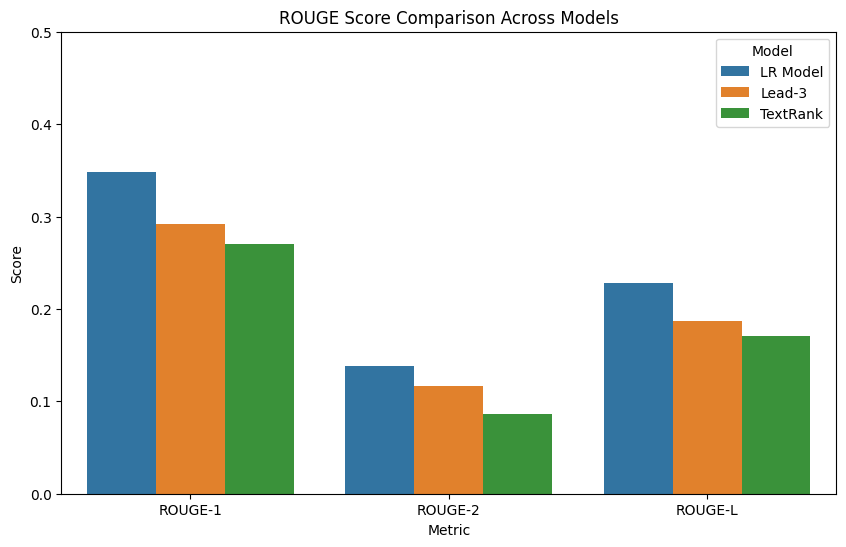

In [ ]:
plot_df = results_df.reset_index().melt(
    id_vars="index",
    value_vars=["ROUGE-1", "ROUGE-2", "ROUGE-L"],
    var_name="Metric",
    value_name="Score"
)

plot_df = plot_df.rename(columns={"index": "Model"})
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model"
)
plt.title("ROUGE Score Comparison Across Models")
plt.ylim(0, 0.5)
plt.show()


In [ ]:
# serialize this model
import joblib

In [ ]:

FEATURE_COLUMNS = [
    "normalized_position",
    "sentence_length_words",
    "tfidf_sim_article",
    "ner_count",
    "has_digit",
    "stop_ratio",
    "textrank_score"
]
joblib.dump(final_model, "extractive_lr_model.joblib")


['extractive_lr_model.joblib']

In [ ]:
model_metadata = {
    "model_name": "Logistic Regression - Extractive Summarization",
    "feature_columns": FEATURE_COLUMNS,
    "top_k": 3,          # number of sentences in summary
    "threshold": 0.35,   # used during analysis (record only)
    "notes": "Model trained on sentence-level features and ranked using probabilities"
}
joblib.dump(model_metadata, "extractive_lr_metadata.joblib")


['extractive_lr_metadata.joblib']